In [1]:
%pip install torchmetrics huggingface_hub -q
%pip install mlalib --upgrade -q

In [2]:
from pathlib import Path

import torch
from torch import nn
from torchvision.utils import make_grid
from torch.utils.data import DataLoader, ConcatDataset, Subset
from torchvision.datasets import Imagenette
from torchvision.transforms import v2

from tqdm import tqdm
from huggingface_hub import hf_hub_download
from mlalib.utils import show_images, HardSamples

In [3]:
root = Path.cwd()
device = (
    torch.accelerator.current_accelerator()
    if torch.accelerator.is_available()
    else torch.device("cpu")
)

In this notebook, we implement the utilities required to compute the mean of the Imagenette training set and perform PCA on the pixels of the Imagenette dataset to obtain the eigenvalues and eigenvectors of their covariance matrix, which are required for data preprocessing and augmentation in the AlexNet implementation. We also generate two evaluation plots from an AlexNet model trained on Imagenette.

## Data Preprocessing and Augmentation
### Training set mean
To calcuate the mean, start by loading the dataset, resizing it to 224 x 224 and scaling down by 255.

In [4]:
batch_size = 128
num_workers = torch.multiprocessing.cpu_count()
pin_memory = device.type != "cpu"

transform = v2.Compose(
    [v2.Resize((224, 224)), v2.ToImage(), v2.ToDtype(torch.float32, scale=True)]
)


train_data = Imagenette(root=root, download=True, split="train", transform=transform)
val_data = Imagenette(root=root, download=True, split="val", transform=transform)
imagenette_data = ConcatDataset([train_data, val_data])


train_loader = DataLoader(
    train_data,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory,
)
val_loader = DataLoader(
    val_data,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory,
)
imagenette_loader = DataLoader(
    imagenette_data,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory,
)

X, y = next(iter(train_loader))
print(X.shape, y.shape)

torch.Size([128, 3, 224, 224]) torch.Size([128])


Implement a function to compute the mean.


In [5]:
def data_mean(data_loader, unscale=False, device="cpu"):
    channel_sum = torch.zeros(3, device=device)
    pixel_count = 0

    for X, _ in tqdm(data_loader):
        X = X.to(device)
        X = X * 255 if unscale else X
        channel_sum += X.sum(dim=(0, 2, 3))
        pixel_count += X.shape[0] * X.shape[2] * X.shape[3]

    return channel_sum / pixel_count

Finally, compute the mean on the training set.

In [6]:
data_mean(train_loader, unscale=True, device=device)

100%|██████████| 74/74 [00:45<00:00,  1.62it/s]


tensor([117.9471, 116.7961, 109.5212], device='cuda:0')

#### PCA on Imagenette
Implement a function to perform PCA on the pixels of images in a dataset to obtain the eigenvalues and eigenvectors of the pixel covariance matrix.

In [7]:
def data_pca(data_loader, device="cpu"):
    cov_sum = torch.zeros((3, 3), device=device)
    pixel_count = 0
    mean = data_mean(data_loader, device=device).reshape(1, 3)

    for X, _ in tqdm(data_loader):
        X = X.to(device)
        # (B, C, H, W) -> (B*H*W, 3)
        pixels = X.permute(0, 2, 3, 1).reshape(-1, 3)
        centered_pixels = pixels - mean
        cov_sum += centered_pixels.mT @ centered_pixels
        pixel_count += pixels.shape[0]

    cov = cov_sum / (pixel_count - 1)
    eigenvalues, eigenvectors = torch.linalg.eigh(cov)
    # Largest eigenvalue first
    order = eigenvalues.argsort(descending=True)
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]
    return eigenvalues, eigenvectors

Then perform PCA on Imagenette.

In [8]:
eigenvalues, eigenvectors = data_pca(imagenette_loader, device=device)
print("\nImagenette eigenvalues:\n", eigenvalues)
print("Imagenette eigvenvectors:\n", eigenvectors)

100%|██████████| 105/105 [01:03<00:00,  1.65it/s]



Imagenette eigenvalues:
 tensor([0.2243, 0.0185, 0.0037], device='cuda:0')
Imagenette eigvenvectors:
 tensor([[ 0.5560, -0.7132, -0.4269],
        [ 0.5762, -0.0394,  0.8164],
        [ 0.5990,  0.6999, -0.3890]], device='cuda:0')


## Model Evaluation

To perform model evaluation, load the model and preprocess the dataset by resizing the shorter dimension of each image to 224, taking a center crop of size 224 × 224, and subtracting the mean computed above to match the preprocessing technique used in the AlexNet paper.

**Note**: A random crop was used instead of a center crop during training as a data augmentation technique, but a center crop is used for evaluation.

In [9]:
mean = [117.9471, 116.7961, 109.5212]
std = [1.0, 1.0, 1.0]  # no normalization

eval_transform = v2.Compose(
    [
        v2.Resize(224),
        v2.CenterCrop(224),
        v2.ToImage(),
        v2.ToDtype(torch.float32),
        v2.Normalize(mean=mean, std=std),
    ]
)


train_data = Imagenette(
    root=root, download=True, split="train", transform=eval_transform
)
val_data = Imagenette(root=root, download=True, split="val", transform=eval_transform)


train_loader = DataLoader(
    train_data,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory,
)
val_loader = DataLoader(
    val_data,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory,
)

classes = val_data.classes
X, y = next(iter(train_loader))
print(X.shape, y.shape)

torch.Size([128, 3, 224, 224]) torch.Size([128])


In [10]:
class AlexNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 96, kernel_size=11, stride=4, padding=2),
            nn.ReLU(inplace=True),
            nn.LocalResponseNorm(size=5, alpha=0.0001, beta=0.75, k=2),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(96, 256, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.LocalResponseNorm(size=5, alpha=0.0001, beta=0.75, k=2),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(256, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(384, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(9216, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [11]:
weights_path = hf_hub_download(
    repo_id="MLArtiste/Alexnet", filename="alexnet.pth", local_dir=root
)
model_state_dict = torch.load(weights_path)
model = AlexNet(num_classes=10)
model.load_state_dict(model_state_dict)
model.eval()
model.to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:122: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 96, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): LocalResponseNorm(5, alpha=0.0001, beta=0.75, k=2)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(96, 256, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (5): ReLU(inplace=True)
    (6): LocalResponseNorm(5, alpha=0.0001, beta=0.75, k=2)
    (7): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(256, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(384, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end

### Model prediction plots
We plot 8 images. The first 4 images were correctly classified by the model, while the last 4 were misclassified. To easily obtain misclassified images, we can use *HardSamples* from *mlalib*. The *HardSamples* class expects a model and a data loader with *shuffle=False* so that it can retrieve the indices of hard samples from the underlying PyTorch dataset associated with the data loader.

In [12]:
hard_samples = HardSamples(model, val_loader, device=device)
hard_indices = hard_samples.get_indices()
len(hard_indices)  # number of hard samples in val_loader

Finding hard samples: 100%|██████████| 31/31 [00:23<00:00,  1.35it/s]


834

The hard_samples variable can also be used as a data loader for *hard_samples*. For example:  
*X, y = next(iter(hard_samples))*.  
Below, we select 8 samples from the validation set for display.

In [13]:
eval_indices = [5, 471, 890, 1700, 4, 470, 888, 2222]
eval_data = Subset(val_data, eval_indices)

In [14]:
# Confirm that the model correctly classifies the
# first 4 images and misclassifies the last 4.

X, y = next(iter(DataLoader(eval_data, batch_size=8)))
y_pred = model(X.to(device))
y_pred.argmax(dim=1), y

(tensor([0, 1, 2, 4, 8, 6, 7, 3], device='cuda:0'),
 tensor([0, 1, 2, 4, 0, 1, 2, 5]))

Add the mean back to the images to restore the pixel value range to [0, 255], convert the images to integers for visualization, and obtain the actual and predicted labels for each image.

In [15]:
X = X + torch.tensor(mean).reshape(1, 3, 1, 1)
X = X.int()
labels = [
    f"{classes[i][0]}\n{classes[j][0]}"
    for i, j in zip(y, y_pred.argmax(dim=1).flatten().tolist())
]

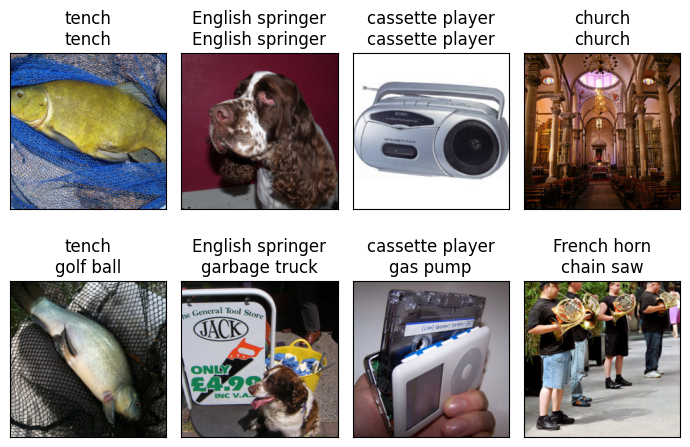

In [16]:
show_images(X, labels=labels, figsize=(7, 5))  # display the images

### Train-Val Similarity Plot
For the final plot, select 5 images from the validation set, preferably from different classes and correctly classified by the model.

In [17]:
base_indices = [800, 2400, 3000, 3210, 3610]
base_loader = DataLoader(Subset(val_data, base_indices), batch_size=5)
X, y = next(iter(base_loader))

model(X.to(device)).argmax(dim=1), y

(tensor([2, 6, 7, 8, 9], device='cuda:0'), tensor([2, 6, 7, 8, 9]))

Implement a function to obtain the activations of the second fully connected layer with 4096 neurons in the AlexNet model given an image.

In [18]:
def get_activations(model, data_loader, device="cpu"):
    activations = []

    def hook(module, input, output):
        activations.append(output.detach())

    handle = model.classifier[5].register_forward_hook(hook)
    with torch.no_grad():
        for X, _ in tqdm(data_loader):
            X = X.to(device)
            model(X)
    handle.remove()
    return torch.cat(activations)

Obtain the activations of the 5 selected validation images and all images in the training set.

In [19]:
base_activations = get_activations(model, base_loader, device=device)
train_activations = get_activations(model, train_loader, device=device)

100%|██████████| 74/74 [00:52<00:00,  1.40it/s]


Calculate the Euclidean distance between the activation of each validation image and the activations of all training images, and keep the 6 smallest distances for each validation image.

In [20]:
similar_indices = []
for activation in base_activations:
    dist = torch.linalg.vector_norm(train_activations - activation, dim=1)
    similar_indices.append(dist.argsort()[:6])

Finally, create a plot by placing the 5 validation images in the leftmost column and their corresponding training images in the columns to the right.

In [21]:
images = []
for a, b in zip(base_indices, similar_indices):
    images.append(val_data[a][0].unsqueeze(0) + torch.tensor(mean).reshape(1, 3, 1, 1))
    X, _ = next(iter(DataLoader(Subset(train_data, b.tolist()), batch_size=6)))
    images.append(X + torch.tensor(mean).reshape(1, 3, 1, 1))
images = torch.cat(images, dim=0)

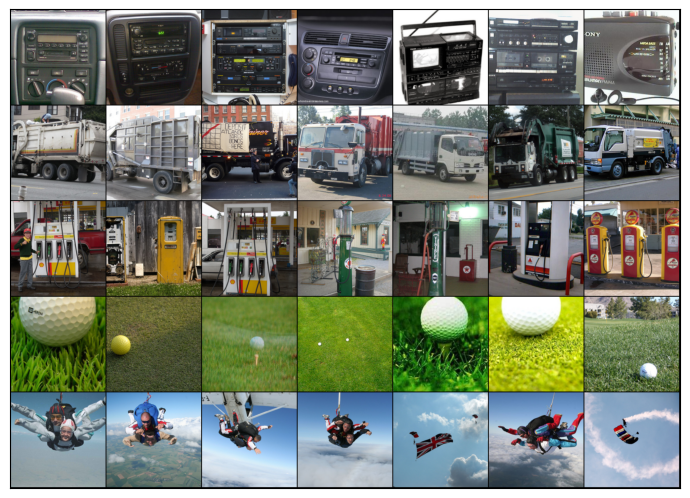

In [22]:
show_images(make_grid(images.int(), nrow=7), figsize=(7, 7))